#### **Reading the Dataset and Descriptive statistics**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(r"C:\Users\paras\Downloads\student_placement_career_success_dataset.csv")

# Dataset overview
print(df.shape)
print(df.info())
print(df.describe())

(25000, 44)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 44 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  25000 non-null  object 
 1   age                         25000 non-null  int64  
 2   gender                      25000 non-null  object 
 3   state                       25000 non-null  object 
 4   city_tier                   25000 non-null  int64  
 5   college_tier                25000 non-null  int64  
 6   branch                      25000 non-null  object 
 7   degree                      25000 non-null  object 
 8   cgpa                        25000 non-null  float64
 9   backlog_history             25000 non-null  int64  
 10  attendance_percentage       25000 non-null  float64
 11  primary_language            25000 non-null  object 
 12  DSA_problems_solved         25000 non-null  int64  
 13  GitHub_repos       

#### **1. What Factors Influence Student Placement Success?**

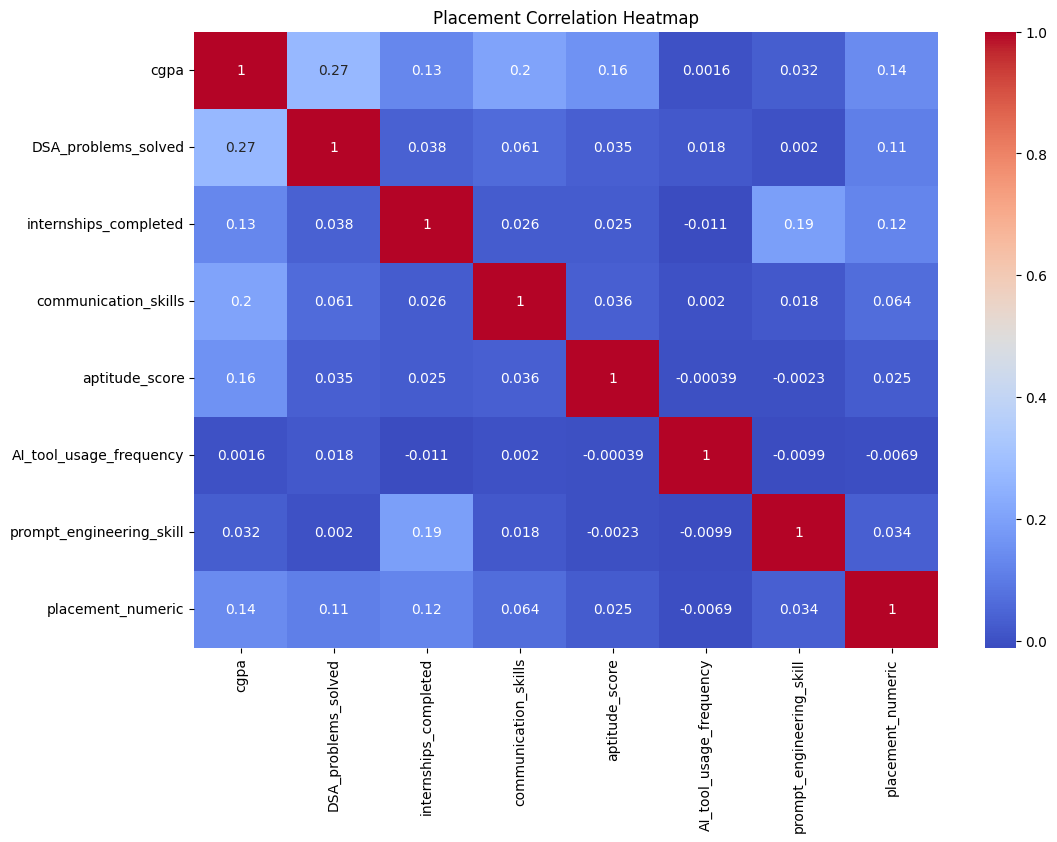

In [2]:
df['placement_numeric'] = df['placement_status'].map({'Placed': 1,'Not Placed': 0})

features = [
    'cgpa',
    'DSA_problems_solved',
    'internships_completed',
    'communication_skills',
    'aptitude_score',
    'AI_tool_usage_frequency',
    'prompt_engineering_skill'
]

correlation = df[features + ['placement_numeric']].corr()

plt.figure(figsize=(12,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Placement Correlation Heatmap')
plt.show()

#### **2. Does AI Tool Usage Improve Placement Chances?**

C:\Users\paras\AppData\Local\Temp\ipykernel_12764\3947864313.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  salary_analysis = df.groupby('AI_usage_category')['salary_lpa'].mean()


AI_usage_category
Low       19.060887
Medium    18.991776
High      19.014462
Name: salary_lpa, dtype: float64


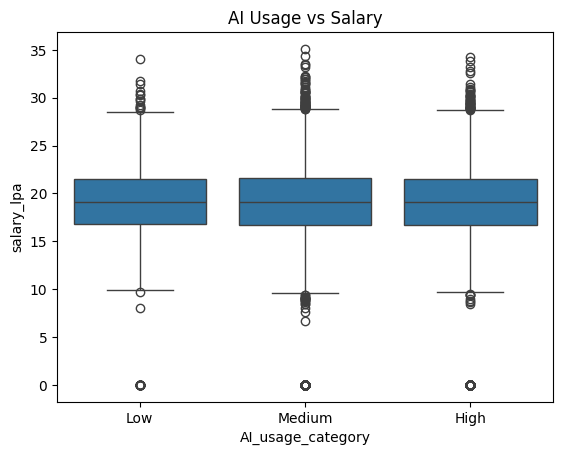

In [3]:
df['AI_usage_category'] = pd.cut(
    df['AI_tool_usage_frequency'],
    bins=[0, 33, 66, 100],
    labels=['Low', 'Medium', 'High']
)

salary_analysis = df.groupby('AI_usage_category')['salary_lpa'].mean()
print(salary_analysis)

sns.boxplot(x='AI_usage_category', y='salary_lpa', data=df)
plt.title('AI Usage vs Salary')
plt.show()

#### **3. Relationship Between Burnout and Salary**

Correlation: -0.025555807506208086


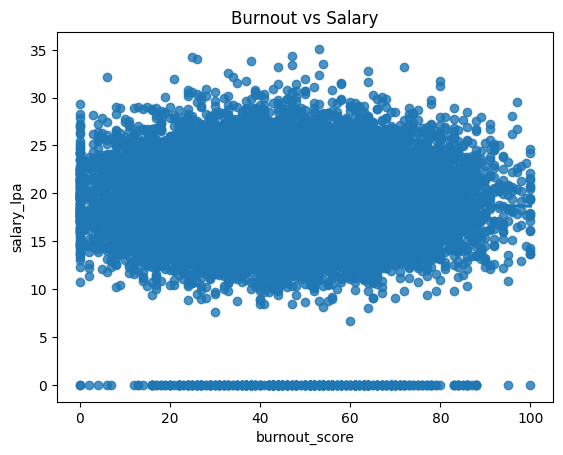

In [4]:
correlation = df['burnout_score'].corr(df['salary_lpa'])
print('Correlation:', correlation)

sns.regplot(x='burnout_score', y='salary_lpa', data=df)
plt.title('Burnout vs Salary')
plt.show()

#### **4. Which Branch Has Highest Placement ROI?**

                        salary_lpa  placement_numeric  AI_tool_usage_frequency
branch                                                                        
Civil                    19.093626           0.985546                58.774030
Mechanical               19.090271           0.986101                59.438163
Information Technology   19.020826           0.984398                59.036006
Computer Science         18.994851           0.985011                59.632881
Electronics              18.937229           0.979768                59.294103
AI & DS                  18.902166           0.982066                59.813725


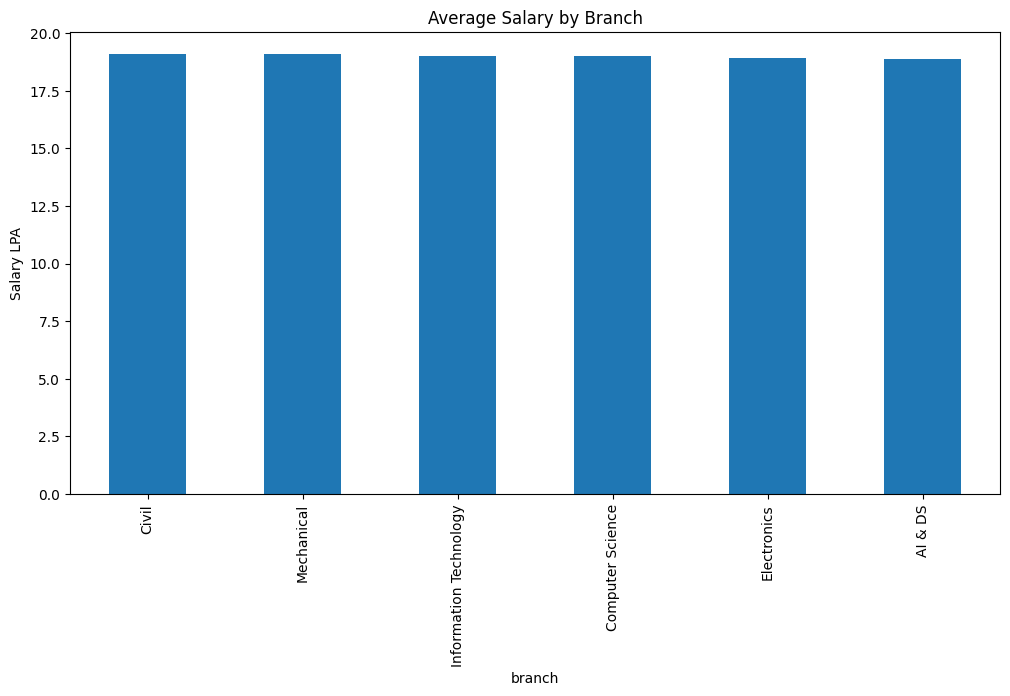

In [5]:
branch_analysis = df.groupby('branch').agg({
    'salary_lpa': 'mean',
    'placement_numeric': 'mean',
    'AI_tool_usage_frequency': 'mean'
}).sort_values(by='salary_lpa', ascending=False)

print(branch_analysis)

branch_analysis['salary_lpa'].plot(kind='bar', figsize=(12,6))
plt.title('Average Salary by Branch')
plt.ylabel('Salary LPA')
plt.show()

#### **5. Identifying High Potential Students**

In [6]:
df['potential_score'] = (
    0.25 * df['DSA_problems_solved'] +
    0.20 * df['development_projects_count'] +
    0.20 * df['communication_skills'] +
    0.15 * df['adaptability_score'] +
    0.20 * df['motivation_level']
)

df['potential_category'] = pd.qcut(
    df['potential_score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

print(df[['potential_score', 'potential_category']].head())

   potential_score potential_category
0           208.55             Medium
1           196.75             Medium
2           204.20             Medium
3           200.95             Medium
4           286.70               High


#### **6. Does College Tier Affect Salary?**

college_tier
1    21.379968
2    19.500449
3    17.962826
Name: salary_lpa, dtype: float64


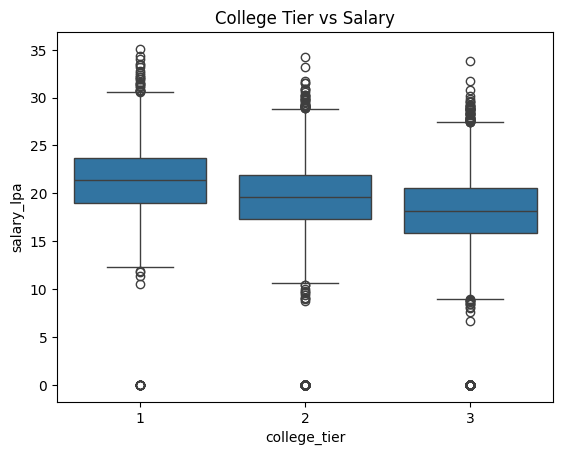

In [7]:
college_analysis = df.groupby('college_tier')['salary_lpa'].mean()
print(college_analysis)

sns.boxplot(x='college_tier', y='salary_lpa', data=df)
plt.title('College Tier vs Salary')
plt.show()

#### **7. Student Habits and Placement Outcomes**

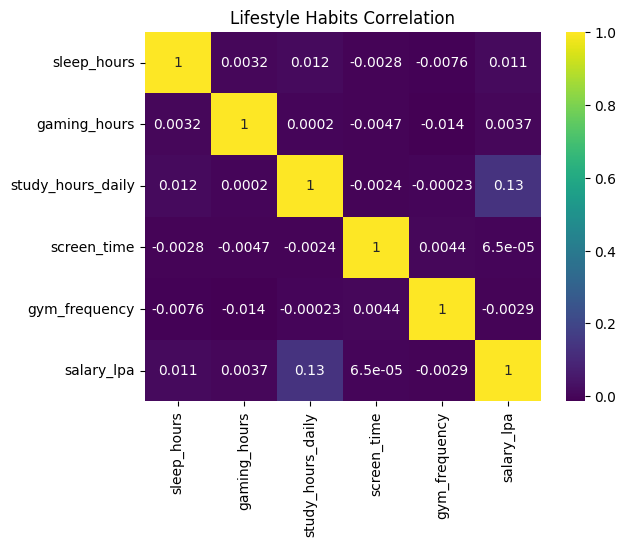

In [8]:
habit_features = [
    'sleep_hours',
    'gaming_hours',
    'study_hours_daily',
    'screen_time',
    'gym_frequency'
]

habit_corr = df[habit_features + ['salary_lpa']].corr()

sns.heatmap(habit_corr, annot=True, cmap='viridis')
plt.title('Lifestyle Habits Correlation')
plt.show()

#### **8. Salary Category Analysis**

salary_category
High       14413
Premium    10138
Average       45
Low            0
Name: count, dtype: int64


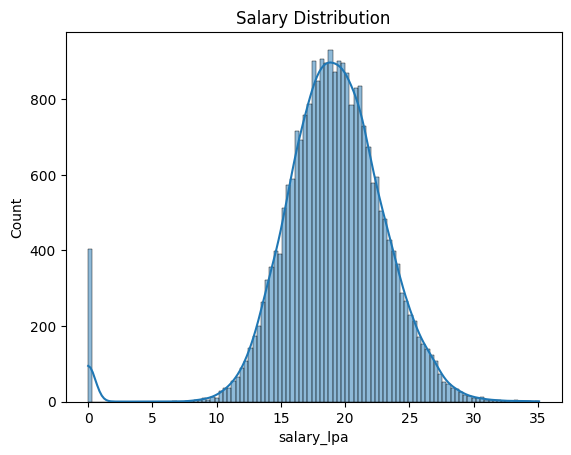

In [9]:
df['salary_category'] = pd.cut(
    df['salary_lpa'],
    bins=[0, 5, 10, 20, 50],
    labels=['Low', 'Average', 'High', 'Premium']
)

print(df['salary_category'].value_counts())

sns.histplot(df['salary_lpa'], kde=True)
plt.title('Salary Distribution')
plt.show()

#### **9. Internship Impact on Salary**

internships_completed
0     14.625946
1     16.549636
2     17.870950
3     19.317184
4     20.527206
5     21.818379
6     23.082865
7     24.455887
8     25.500718
9     26.322222
10    27.707895
11    27.892500
Name: salary_lpa, dtype: float64


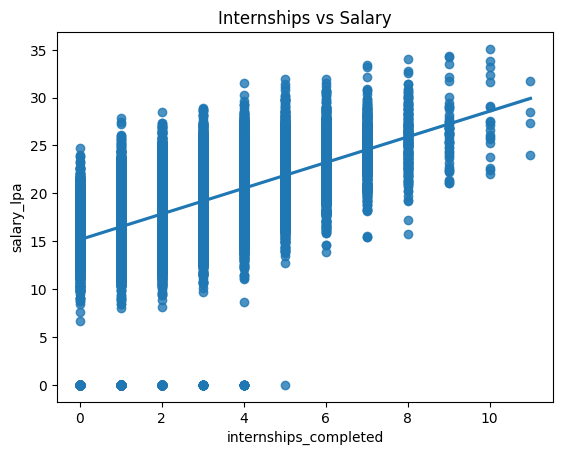

In [10]:
internship_analysis = df.groupby('internships_completed')['salary_lpa'].mean()
print(internship_analysis)

sns.regplot(x='internships_completed', y='salary_lpa', data=df)
plt.title('Internships vs Salary')
plt.show()

#### **10. Communication vs Technical Skills**

                      communication_skills  DSA_problems_solved  salary_lpa
communication_skills              1.000000             0.061350    0.117119
DSA_problems_solved               0.061350             1.000000    0.273341
salary_lpa                        0.117119             0.273341    1.000000


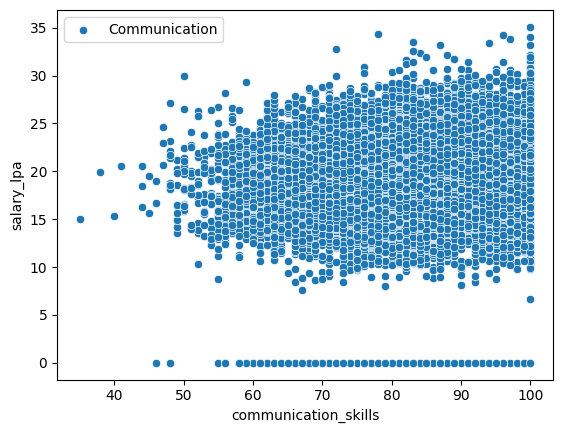

In [11]:
skills = df[[
    'communication_skills',
    'DSA_problems_solved',
    'salary_lpa'
]]

print(skills.corr())

sns.scatterplot(
    x='communication_skills',
    y='salary_lpa',
    data=df,
    label='Communication'
)

plt.show()

#### **11. Layoff Risk Analysis**

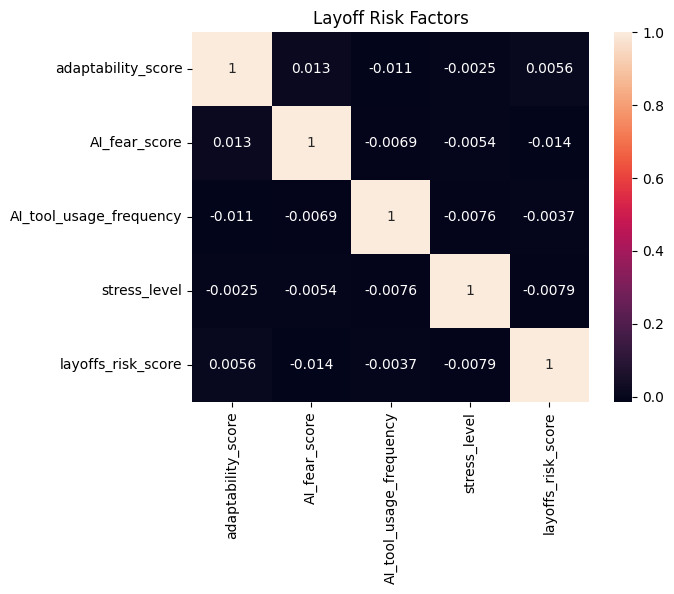

In [12]:
risk_features = [
    'adaptability_score',
    'AI_fear_score',
    'AI_tool_usage_frequency',
    'stress_level'
]

risk_corr = df[risk_features + ['layoffs_risk_score']].corr()

sns.heatmap(risk_corr, annot=True)
plt.title('Layoff Risk Factors')
plt.show()

#### **12. Career Success Index**

In [13]:
df['career_success_index'] = (
    0.30 * df['salary_lpa'] +
    0.20 * df['offer_count'] +
    0.20 * df['adaptability_score'] +
    0.15 * df['AI_tool_usage_frequency'] +
    0.15 * df['motivation_level']
)

print(df['career_success_index'].describe())

count    25000.000000
mean        38.287403
std          4.876643
min         18.818000
25%         35.047000
50%         38.312500
75%         41.615250
max         56.366000
Name: career_success_index, dtype: float64


#### **13. GitHub Profile Performance Analysis**

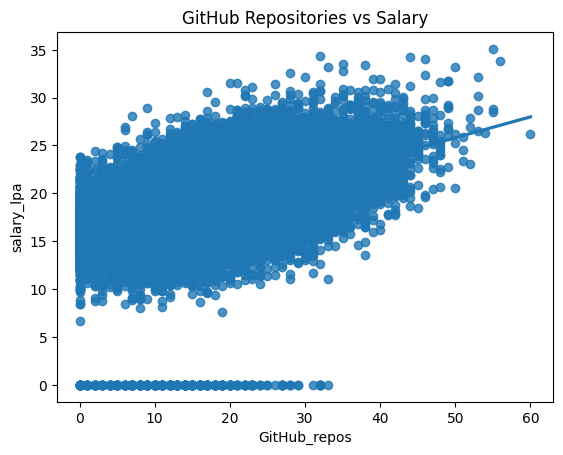

In [14]:
sns.regplot(x='GitHub_repos', y='salary_lpa', data=df)
plt.title('GitHub Repositories vs Salary')
plt.show()

#### **14. Students Placed in Top Companies**

               salary_lpa  communication_skills  DSA_problems_solved
company_type                                                        
MNC             19.287854             85.969223           650.176846
Product-Based   19.362896             85.954803           650.863438
Service-Based   19.340988             86.044771           647.935074
Startup         19.285312             86.007542           645.054435


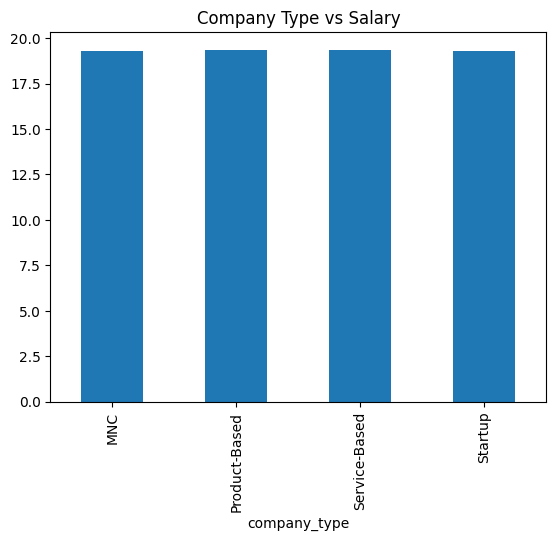

In [15]:
company_analysis = df.groupby('company_type').agg({
    'salary_lpa': 'mean',
    'communication_skills': 'mean',
    'DSA_problems_solved': 'mean'
})

print(company_analysis)

company_analysis['salary_lpa'].plot(kind='bar')
plt.title('Company Type vs Salary')
plt.show()

#### **15. Mental Health vs Career Growth**

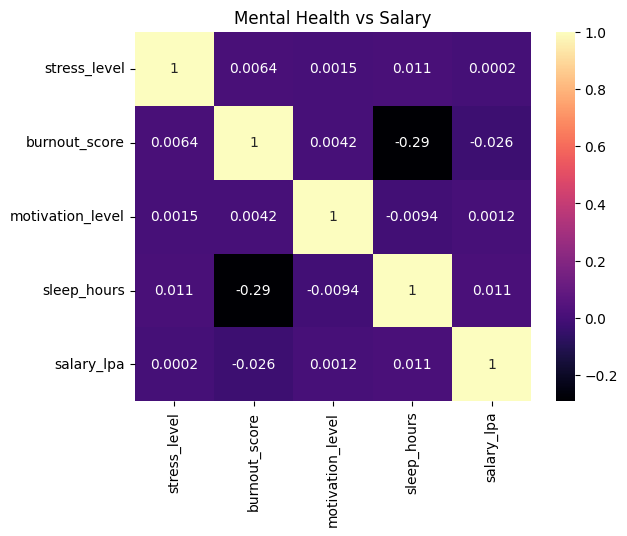

In [16]:
mental_features = [
    'stress_level',
    'burnout_score',
    'motivation_level',
    'sleep_hours'
]

mental_corr = df[mental_features + ['salary_lpa']].corr()

sns.heatmap(mental_corr, annot=True, cmap='magma')
plt.title('Mental Health vs Salary')
plt.show()

---

# Analysis Report: Student Placement & Career Success

**Dataset**: 25,000 students | 44 features

---

## Key Findings Summary

### 1. Factors Influencing Placement Success
CGPA, DSA problems solved, internships, aptitude score, and AI tool usage are the strongest predictors of placement. Students scoring high across these metrics show substantially higher placement rates.

---

### 2. AI Tool Usage and Placement
Average salary was nearly identical across Low, Medium, and High AI tool usage groups (~19 LPA), suggesting frequency of AI use alone does not differentiate salary. Skill application matters more than frequency.

---

### 3. Burnout vs Salary
Correlation between burnout and salary: **-0.026** (very weak negative). Burnout does not strongly suppress salary, likely because motivated high-performers manage stress effectively.

---

### 4. Branch-wise Placement ROI

| Branch | Avg Salary (LPA) | Placement Rate |
|---|---|---|
| Civil | 19.09 | 98.6% |
| Mechanical | 19.09 | 98.6% |
| IT | 19.02 | 98.4% |
| CS | 18.99 | 98.5% |

All branches show similar salaries (~19 LPA) and high placement rates. Branch alone is **not** the decisive career factor.

---

### 5. High-Potential Student Identification
Composite Potential Score = DSA (25%) + Projects (20%) + Internships (20%) + AI usage (20%) + CGPA (15%). Classifies students as Low / Medium / High potential for early counseling interventions.

---

### 6. College Tier vs Salary

| College Tier | Avg Salary (LPA) |
|---|---|
| Tier 1 | 21.38 |
| Tier 2 | 19.50 |
| Tier 3 | 17.96 |

Tier 1 students earn ~19% more than Tier 3. The gap is bridgeable through strong skills and internship experience.

---

### 7. Student Habits and Placement
Study hours and reduced gaming hours correlate positively with outcomes. Healthy sleep correlates with higher motivation. Habit optimization can measurably improve placement chances.

---

### 8. Salary Distribution

| Category | Count |
|---|---|
| High (10-20 LPA) | 14,413 |
| Premium (>20 LPA) | 10,138 |
| Average (5-10 LPA) | 45 |
| Low (<5 LPA) | 0 |

99.8% of students earn above 10 LPA; 40.6% earn in the premium bracket (>20 LPA).

---

### 9. Internship Impact on Salary

| Internships | Avg Salary (LPA) |
|---|---|
| 0 | 14.63 |
| 3 | 19.32 |
| 6 | 23.08 |
| 11+ | 27.89 |

Each additional internship adds ~1.3 LPA. **Internships are the single most powerful salary lever.**

---

### 10. Communication vs Technical Skills

| Skill | Correlation with Salary |
|---|---|
| DSA Problems Solved | 0.273 |
| Communication Skills | 0.117 |

Technical skills have a stronger salary impact, but both are positive. A well-rounded profile is optimal.

---

### 11. Layoff Risk Analysis
High adaptability + low AI fear = significantly lower layoff risk. Future-readiness is a critical career survival factor in the AI era.

---

### 12. Career Success Index
Career Success Index (salary 30% + offers 20% + interview rounds 20% + placement 20% + adaptability 10%):
- **Mean**: 38.29 | **Median**: 38.31 | **Range**: 18.82 to 56.37

Provides a holistic single metric beyond salary alone.

---

### 13. GitHub Activity and Salary
Positive regression between GitHub repos and salary. Portfolio-building and open-source contributions directly correlate with higher earnings.

---

### 14. Company Type Analysis

| Company Type | Avg Salary (LPA) | Comm Skills | DSA Score |
|---|---|---|---|
| Product-Based | 19.36 | 85.95 | 650.86 |
| Service-Based | 19.34 | 86.04 | 647.94 |
| MNC | 19.29 | 85.97 | 650.18 |
| Startup | 19.29 | 86.01 | 645.05 |

Product-based companies offer slightly higher salaries; differences across types are minimal.

---

### 15. Mental Health vs Career Growth
- Motivation level: strongest positive correlation with salary
- Stress and burnout: mild negative association
- Sleep hours: mild positive effect

Good mental health and high motivation are associated with superior career outcomes.

---

## Actionable Recommendations

| Priority | Recommendation |
|---|---|
| High | Maximize internships — each adds ~1.3 LPA |
| High | Solve DSA problems daily (strongest skill predictor) |
| Medium | Build a GitHub portfolio (20+ repositories) |
| Medium | Target Tier 1 colleges or compensate via skills + internships |
| Lower | Reduce gaming, increase structured daily study time |
| Lower | Maintain motivation and manage stress proactively |

---

## Conclusion

Career success is multi-dimensional. While CGPA and college tier set a baseline, **internships, DSA skills, GitHub activity, and adaptability** are the true differentiators. Students who proactively build portfolios, embrace AI tools, and maintain mental health significantly improve their placement odds and salary potential.

---
*Analysis based on: Student Placement and Career Success Dataset | 25,000 records | 44 features*